<a href="https://colab.research.google.com/github/soulqan/PCVK_GANJIL_2025/blob/main/week_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import library yang dibutuhkan
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt
import os # Tambahan untuk mengelola path file

In [2]:
# Mengakses Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [6]:
# --- PENTING! ---
# Sesuaikan path ini dengan lokasi folder tempat Anda menyimpan gambar praktikum
# Contoh: '/content/drive/MyDrive/Kuliah/PCVK/Images_Modul11/'
BASE_PATH = '/content/drive/MyDrive/images/Object-Detection'

# # Kita buat folder haarcascades jika belum ada (sesuai modul)
HAAR_PATH = os.path.join(BASE_PATH, 'haarcascades')
if not os.path.exists(HAAR_PATH):
    os.makedirs(HAAR_PATH)

print("Setup Selesai. Library diimpor dan Drive terhubung.")
print(f"Pastikan gambar ada di: {BASE_PATH}")
print(f"Pastikan file XML haarcascade ada di: {HAAR_PATH}")

# Anda perlu mengunduh file XML Haarcascade dan meletakkannya di folder HAAR_PATH
# File yang umum dibutuhkan dari modul ini:
# - haarcascade_frontalface_alt.xml
# - haarcascade_frontalcatface.xml
# - haarcascade_eye.xml
# - haarcascade_smile.xml
#
# Anda bisa mengunduhnya dari repository OpenCV di GitHub:
# https://github.com/opencv/opencv/tree/master/data/haarcascades

Setup Selesai. Library diimpor dan Drive terhubung.
Pastikan gambar ada di: /content/drive/MyDrive/images/Object-Detection
Pastikan file XML haarcascade ada di: /content/drive/MyDrive/images/Object-Detection/haarcascades


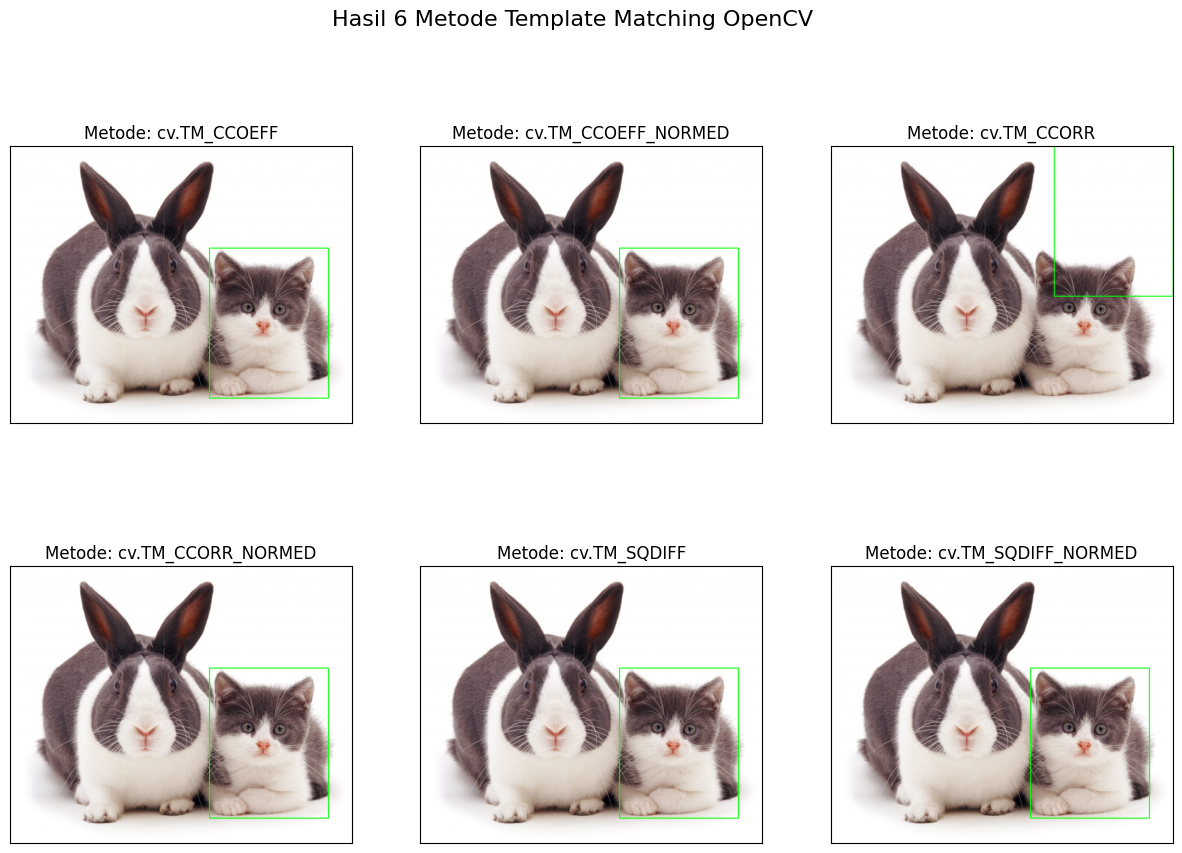

In [6]:
# Muat gambar sumber dan template
img_path = os.path.join(BASE_PATH, 'cats_and_bunnies.jpg')
template_path = os.path.join(BASE_PATH, 'cat2_templatejpg.jpg') # Sesuai nama file di modul

img = cv.imread(img_path)
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
template = cv.imread(template_path, 0)
w, h = template.shape[::-1]

# Daftar 6 metode untuk diiterasi [cite: 539-545]
methods = ['cv.TM_CCOEFF', 'cv.TM_CCOEFF_NORMED', 'cv.TM_CCORR',
           'cv.TM_CCORR_NORMED', 'cv.TM_SQDIFF', 'cv.TM_SQDIFF_NORMED']

# Siapkan plot
plt.figure(figsize=(15, 10))

for i, meth_name in enumerate(methods):
    img_draw = img.copy() # Salin gambar asli untuk digambar
    method = eval(meth_name) # Mengubah string menjadi konstanta OpenCV, misal 'cv.TM_CCOEFF'

    # Terapkan Template Matching [cite: 536]
    res = cv.matchTemplate(img_gray, template, method)

    # Dapatkan lokasi kecocokan terbaik
    min_val, max_val, min_loc, max_loc = cv.minMaxLoc(res)

    # Untuk metode SQDIFF dan SQDIFF_NORMED, kecocokan terbaik adalah nilai minimum
    if method in [cv.TM_SQDIFF, cv.TM_SQDIFF_NORMED]:
        top_left = min_loc
    else:
        top_left = max_loc

    bottom_right = (top_left[0] + w, top_left[1] + h)

    # Gambar kotak di lokasi yang ditemukan
    cv.rectangle(img_draw, top_left, bottom_right, (0, 255, 0), 2)

    # Tampilkan hasil
    plt.subplot(2, 3, i+1)
    plt.imshow(cv.cvtColor(img_draw, cv.COLOR_BGR2RGB))
    plt.title(f'Metode: {meth_name}')
    plt.xticks([]), plt.yticks([])

plt.suptitle('Hasil 6 Metode Template Matching OpenCV', fontsize=16)
plt.show()

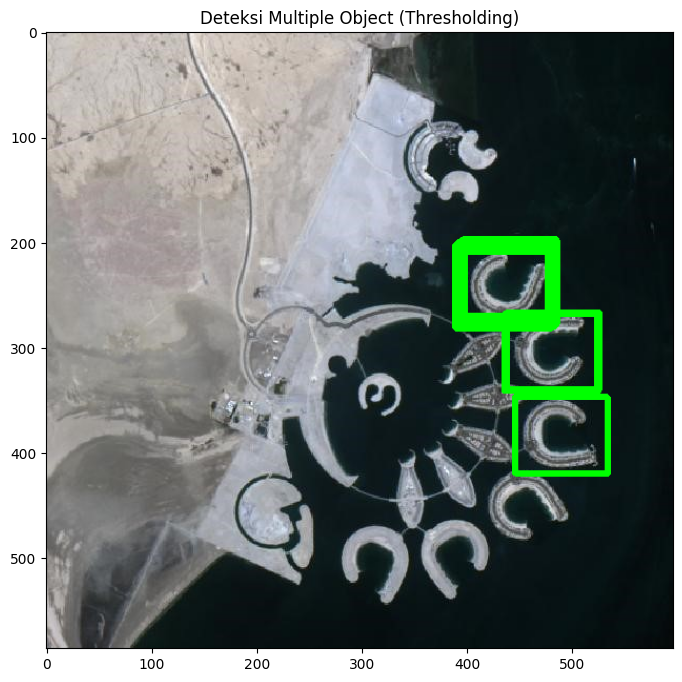

In [14]:
# Muat gambar sumber dan template
img_path = os.path.join(BASE_PATH, 'bahrain.jpg')
template_path = os.path.join(BASE_PATH, 'bahrain-template.jpg')

img_rgb = cv.imread(img_path)
img_gray = cv.cvtColor(img_rgb, cv.COLOR_BGR2GRAY)
template = cv.imread(template_path, 0)
w, h = template.shape[::-1]

# Gunakan metode TM_CCOEFF_NORMED karena paling andal untuk thresholding
res = cv.matchTemplate(img_gray, template, cv.TM_CCOEFF_NORMED)

# Tentukan threshold. Anda mungkin perlu menyesuaikan nilai ini.
threshold = 0.5

# Dapatkan semua lokasi yang memiliki nilai di atas threshold
loc = np.where(res >= threshold)

# Gambar kotak untuk setiap lokasi yang ditemukan
# zip(*loc[::-1]) menukar (row, col) menjadi (x, y)
for pt in zip(*loc[::-1]):
    cv.rectangle(img_rgb, pt, (pt[0] + w, pt[1] + h), (0, 255, 0), 2)

# Tampilkan hasil
plt.figure(figsize=(10, 8))
plt.imshow(cv.cvtColor(img_rgb, cv.COLOR_BGR2RGB))
plt.title('Deteksi Multiple Object (Thresholding)')
plt.show()

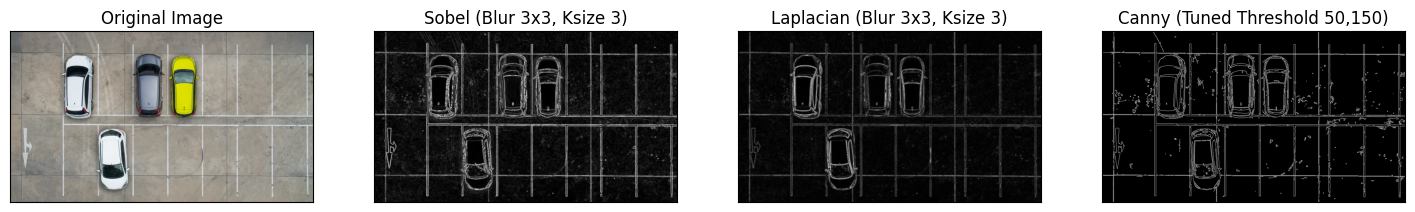

In [19]:
# Muat gambar
img_path = os.path.join(BASE_PATH, 'car-park.jpg')
img = cv.imread(img_path)

# --- PERBAIKAN TYPO DI SINI ---
# Seharusnya cv.COLOR_BGR2GRAY (pakai angka 2)
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
# --- AKHIR PERBAIKAN ---

# Gunakan blur, tapi dengan kernel 3x3 agar tidak terlalu halus
img_blur = cv.GaussianBlur(img_gray, (3, 3), 0)

# 1. Sobel Edge Detection
# Gunakan ksize=3
sobelx = cv.Sobel(img_blur, cv.CV_64F, 1, 0, ksize=3)
sobely = cv.Sobel(img_blur, cv.CV_64F, 0, 1, ksize=3)
sobel_combined = cv.magnitude(sobelx, sobely)
sobel_combined = np.uint8(np.absolute(sobel_combined))

# 2. Laplacian Edge Detection
laplacian = cv.Laplacian(img_blur, cv.CV_64F, ksize=3)
laplacian = np.uint8(np.absolute(laplacian))

# 3. Canny Edge Detection
# Terapkan pada img_gray asli dan sesuaikan threshold
canny = cv.Canny(img_gray, 50, 150)

# Tampilkan hasil
plt.figure(figsize=(18, 6))

plt.subplot(1, 4, 1)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title('Original Image')
plt.xticks([]), plt.yticks([])

plt.subplot(1, 4, 2)
plt.imshow(sobel_combined, cmap='gray')
plt.title('Sobel (Blur 3x3, Ksize 3)')
plt.xticks([]), plt.yticks([])

plt.subplot(1, 4, 3)
plt.imshow(laplacian, cmap='gray')
plt.title('Laplacian (Blur 3x3, Ksize 3)')
plt.xticks([]), plt.yticks([])

plt.subplot(1, 4, 4)
plt.imshow(canny, cmap='gray')
plt.title('Canny (Tuned Threshold 50,150)')
plt.xticks([]), plt.yticks([])

plt.show()

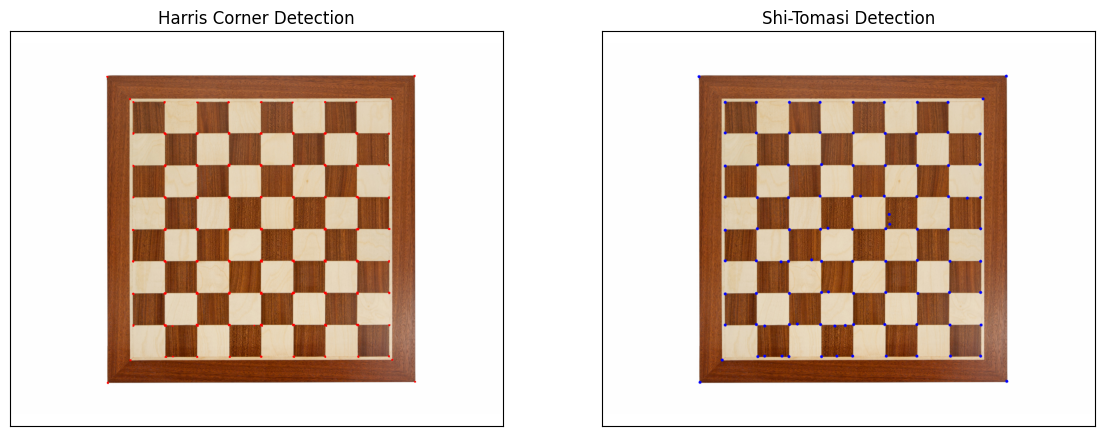

In [10]:
# Sel 5: Harris dan Shi-Tomasi Corner Detection (Perbaikan)

# Muat gambar
img_path = os.path.join(BASE_PATH, 'chess-board.jpg')
img_harris = cv.imread(img_path)
img_shi = img_harris.copy() # Salin gambar untuk Shi-Tomasi
gray_harris = cv.cvtColor(img_harris, cv.COLOR_BGR2GRAY)
gray_shi = cv.cvtColor(img_shi, cv.COLOR_BGR2GRAY)

# 1. Harris Corner Detection
gray_harris = np.float32(gray_harris)
# Parameter: (img, blockSize, ksize, k)
dst = cv.cornerHarris(gray_harris, 2, 3, 0.04)
# Dilatasi untuk menandai sudut
dst = cv.dilate(dst, None)
# Terapkan threshold dan gambar lingkaran merah
img_harris[dst > 0.01 * dst.max()] = [0, 0, 255]

# 2. Shi-Tomasi Corner Detection
# Parameter: (img, maxCorners, qualityLevel, minDistance)
corners = cv.goodFeaturesToTrack(gray_shi, 100, 0.01, 10)

# --- PERBAIKAN ---
# Mengganti np.int0 yang sudah deprecated dengan np.int_
corners = np.int_(corners)
# --- AKHIR PERBAIKAN ---

# Gambar lingkaran biru
for i in corners:
    x, y = i.ravel()
    cv.circle(img_shi, (x, y), 3, (255, 0, 0), -1)

# Tampilkan hasil
plt.figure(figsize=(14, 7))
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(img_harris, cv.COLOR_BGR2RGB))
plt.title('Harris Corner Detection')
plt.xticks([]), plt.yticks([])

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(img_shi, cv.COLOR_BGR2RGB))
plt.title('Shi-Tomasi Detection')
plt.xticks([]), plt.yticks([])

plt.show()

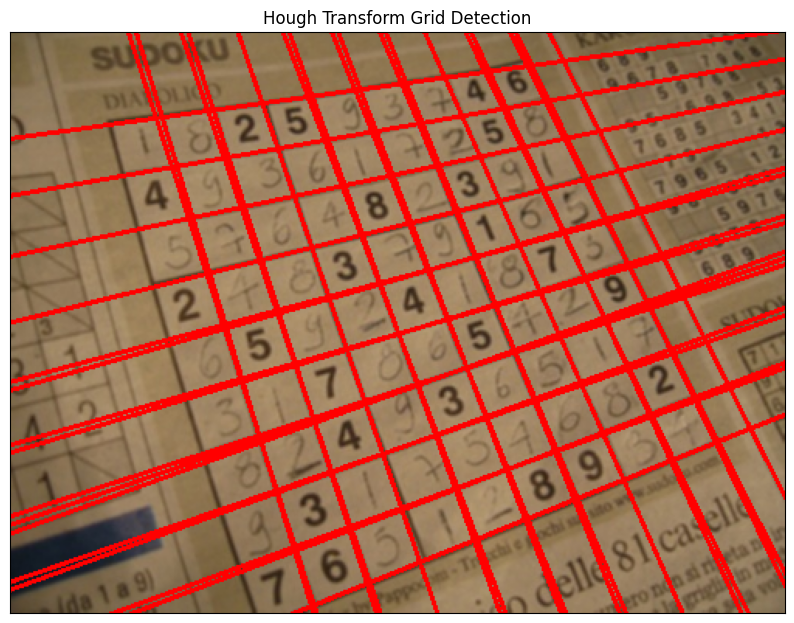

In [37]:
# Muat gambar
img_path = os.path.join(BASE_PATH, 'sudoku.jpg')
img = cv.imread(img_path)
img_hough = img.copy() # Salin untuk menggambar garis
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Tahapan sesuai modul [cite: 236-240]
# 1. Canny Edge Detection
edges = cv.Canny(gray, 50, 150, apertureSize=3)

# --- TAMBAHKAN INI ---
# Definisikan kernel untuk dilasi/erosi
kernel = np.ones((3,3),np.uint8)

# 2. Dilasi (Aktifkan baris ini) [cite: 237]
edges = cv.dilate(edges, kernel, iterations=1)

# 3. Erosi (Aktifkan baris ini)
edges = cv.erode(edges, kernel, iterations=1)
# --- AKHIR PERUBAHAN ---

# 4. Menerapkan HoughLines
# 'edges' sekarang adalah gambar yang sudah di-dilate dan di-erode
# Anda mungkin perlu menyesuaikan threshold (200) jika hasilnya terlalu banyak/sedikit
lines = cv.HoughLines(edges, 1, np.pi / 180, 285)

if lines is not None:
    for line in lines:
        rho, theta = line[0]
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        # Buat titik-titik garis yang panjang
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))
        cv.line(img_hough, (x1, y1), (x2, y2), (0, 0, 255), 2)

# Tampilkan hasil
plt.figure(figsize=(10, 8))
plt.imshow(cv.cvtColor(img_hough, cv.COLOR_BGR2RGB))
plt.title('Hough Transform Grid Detection')
plt.xticks([]), plt.yticks([])
plt.show()

Jumlah kontur terdeteksi: 217


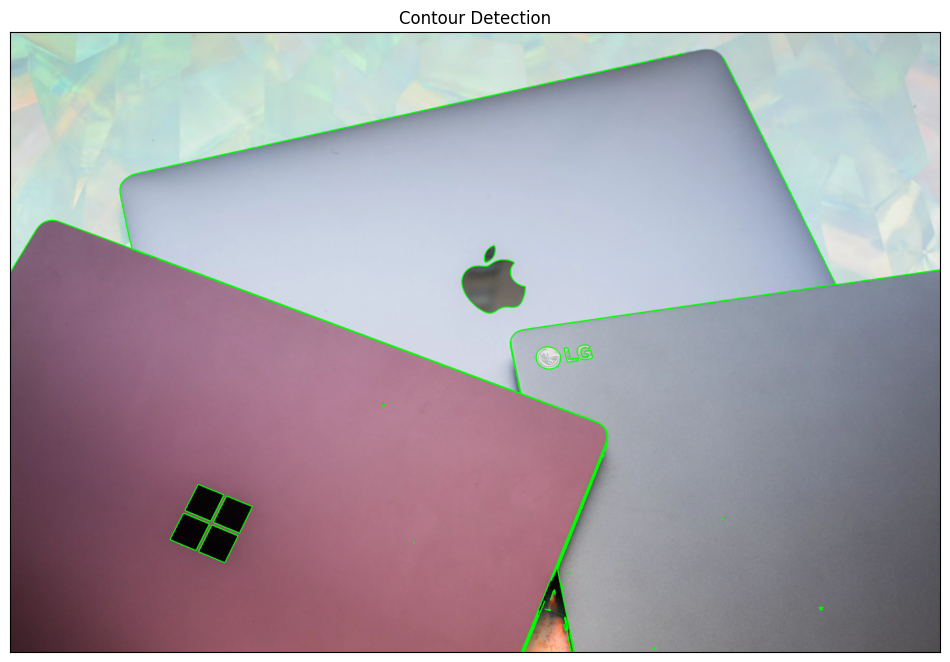

In [38]:
# Muat gambar
img_path = os.path.join(BASE_PATH, 'laptop.jpg')
img = cv.imread(img_path)
img_contour = img.copy() # Salin untuk menggambar kontur
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Tahapan sesuai modul [cite: 277-279]
# 1. Ubah jadi citra biner (menggunakan Canny)
edged = cv.Canny(gray, 30, 200)

# 2. Menemukan kontur
# Gunakan RETR_EXTERNAL untuk hanya kontur terluar
contours, hierarchy = cv.findContours(edged,
    cv.RETR_EXTERNAL, cv.CHAIN_APPROX_NONE)

print(f"Jumlah kontur terdeteksi: {len(contours)}")

# 3. Menggambarkan kontur
# Parameter: (img, contours, contourIdx, color, thickness)
# contourIdx = -1 berarti menggambar semua kontur
cv.drawContours(img_contour, contours, -1, (0, 255, 0), 3)

# Tampilkan hasil
plt.figure(figsize=(12, 10))
plt.imshow(cv.cvtColor(img_contour, cv.COLOR_BGR2RGB))
plt.title('Contour Detection')
plt.xticks([]), plt.yticks([])
plt.show()

# D2. Praktikum Feature Matching dan Face Detection

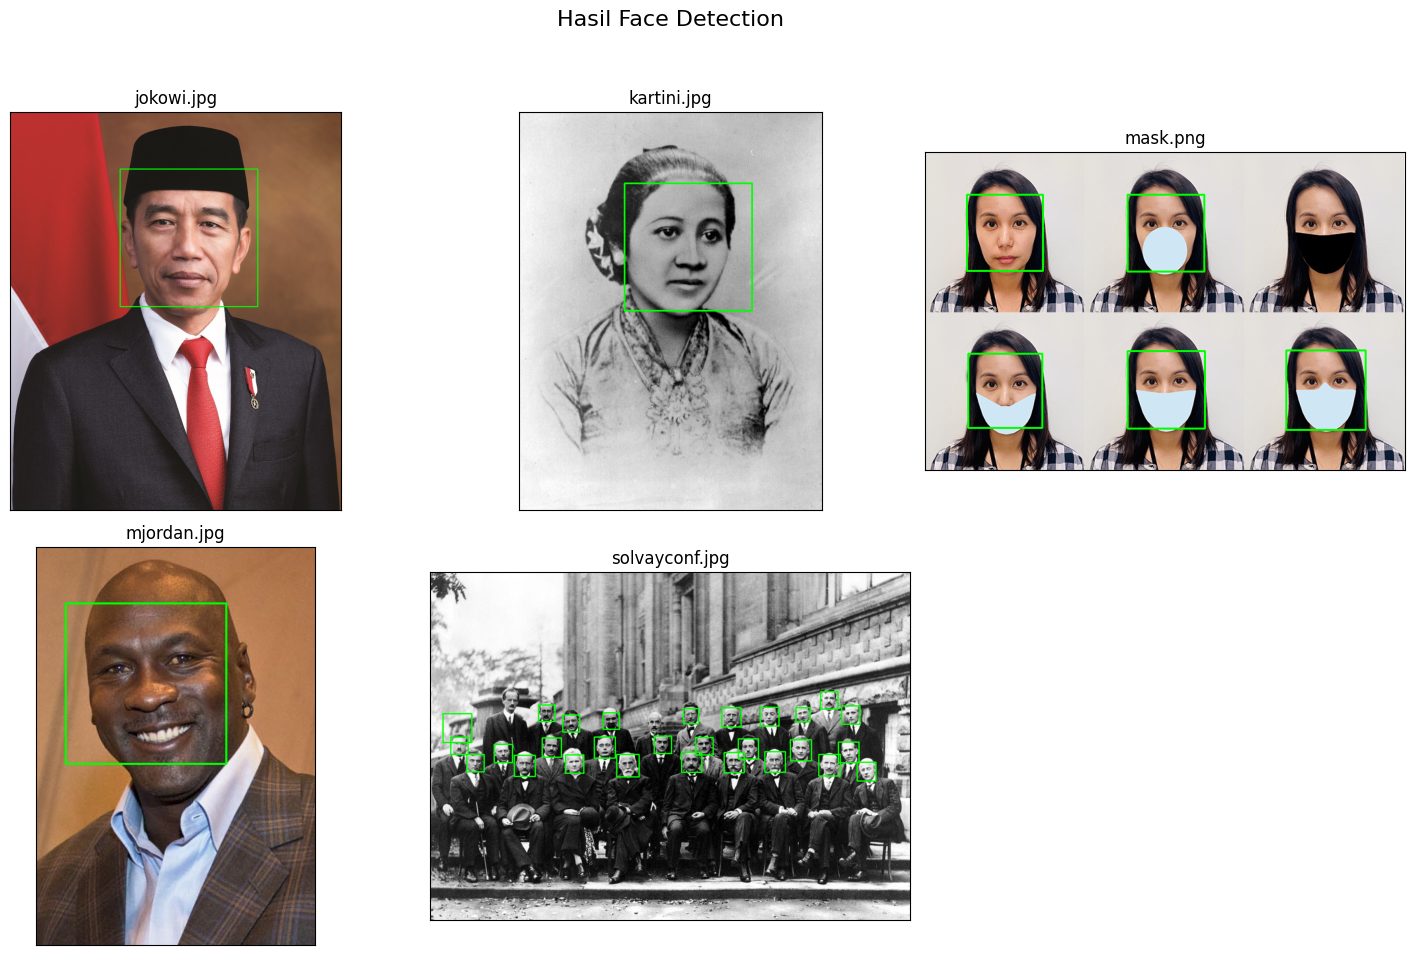

In [44]:
# Muat Haar Cascade classifier untuk wajah [cite: 491]
face_cascade_path = os.path.join(HAAR_PATH, 'haarcascade_frontalface_alt.xml')
face_cascade = cv.CascadeClassifier(face_cascade_path)

if face_cascade.empty():
    print(f"Error: Tidak bisa memuat cascade classifier dari {face_cascade_path}")
    print("Pastikan file XML ada di path yang benar.")
else:
    # Daftar gambar yang akan dideteksi (sesuai gambar di modul [cite: 729])
    image_files = ['jokowi.jpg', 'kartini.jpg', 'mask.png', 'mjordan.jpg', 'solvayconf.jpg']

    plt.figure(figsize=(15, 10))

    for i, filename in enumerate(image_files):
        # Muat gambar
        img_path = os.path.join(BASE_PATH, 'facedet', filename)
        img = cv.imread(img_path)
        if img is None:
            print(f"Warning: Gagal memuat {img_path}")
            continue

        gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

        # Deteksi wajah [cite: 493]
        # Parameter: (img, scaleFactor, minNeighbors)
        faces = face_cascade.detectMultiScale(gray, 1.1, 4)

        # Gambar kotak untuk setiap wajah yang terdeteksi
        for (x, y, w, h) in faces:
            cv.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)

        # Tampilkan hasil
        plt.subplot(2, 3, i+1)
        plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(filename)
        plt.xticks([]), plt.yticks([])

    plt.suptitle('Hasil Face Detection', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

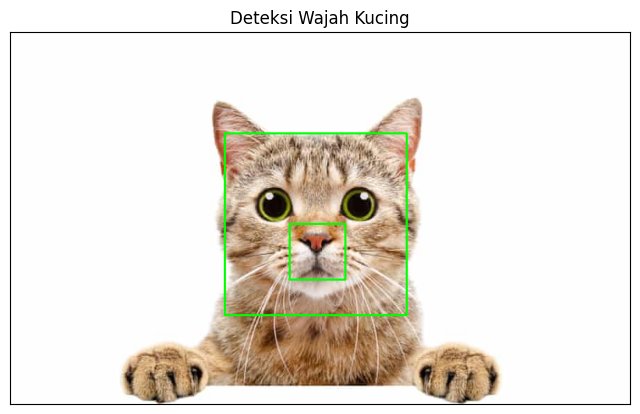

In [46]:
# Muat Haar Cascade classifier untuk wajah KUCING [cite: 733]
cat_cascade_path = os.path.join(HAAR_PATH, 'haarcascade_frontalcatface.xml')
cat_cascade = cv.CascadeClassifier(cat_cascade_path)

if cat_cascade.empty():
    print(f"Error: Tidak bisa memuat cascade classifier dari {cat_cascade_path}")
else:
    # Muat gambar kucing
    img_path = os.path.join(BASE_PATH, 'facedet', 'kucing.jpg')
    img = cv.imread(img_path)
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    # Deteksi wajah kucing
    cat_faces = cat_cascade.detectMultiScale(gray, 1.1, 3)

    # Gambar kotak
    for (x, y, w, h) in cat_faces:
        cv.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)

    # Tampilkan hasil
    plt.figure(figsize=(8, 6))
    plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    plt.title('Deteksi Wajah Kucing')
    plt.xticks([]), plt.yticks([])
    plt.show()

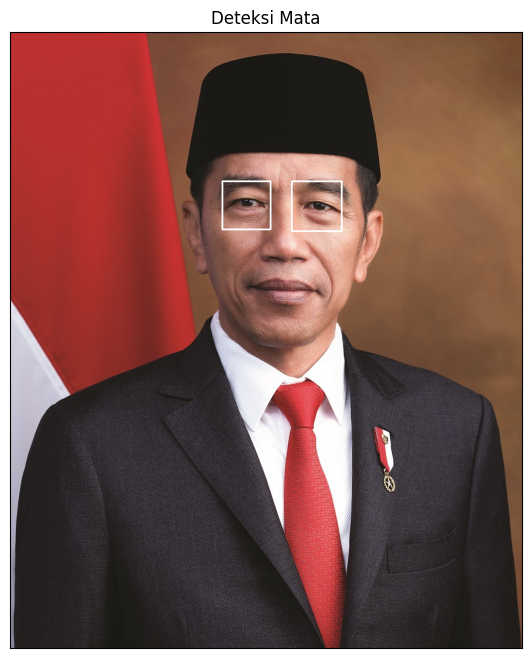

In [47]:
# Muat cascade untuk wajah dan mata
face_cascade_path = os.path.join(HAAR_PATH, 'haarcascade_frontalface_alt.xml')
eye_cascade_path = os.path.join(HAAR_PATH, 'haarcascade_eye.xml')

face_cascade = cv.CascadeClassifier(face_cascade_path)
eye_cascade = cv.CascadeClassifier(eye_cascade_path)

if face_cascade.empty() or eye_cascade.empty():
    print("Error: Gagal memuat cascade classifier untuk wajah atau mata.")
else:
    # Muat gambar
    img_path = os.path.join(BASE_PATH, 'facedet', 'jokowi.jpg')
    img = cv.imread(img_path)
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    # Pertama, deteksi wajah
    faces = face_cascade.detectMultiScale(gray, 1.1, 4)

    for (x, y, w, h) in faces:
        # Tentukan Region of Interest (ROI) hanya di area wajah
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = img[y:y+h, x:x+w]

        # Deteksi mata di dalam ROI wajah
        eyes = eye_cascade.detectMultiScale(roi_gray, 1.1, 5)

        # Gambar kotak untuk mata di dalam ROI
        for (ex, ey, ew, eh) in eyes:
            cv.rectangle(roi_color, (ex, ey), (ex+ew, ey+eh), (255, 255, 255), 2)

    # Tampilkan hasil
    plt.figure(figsize=(8, 8))
    plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    plt.title('Deteksi Mata')
    plt.xticks([]), plt.yticks([])
    plt.show()

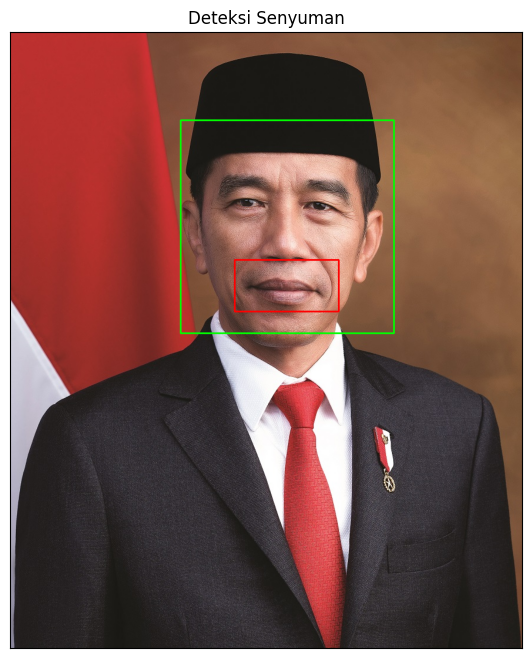

In [48]:
# Muat cascade untuk wajah dan senyum
face_cascade_path = os.path.join(HAAR_PATH, 'haarcascade_frontalface_alt.xml')
smile_cascade_path = os.path.join(HAAR_PATH, 'haarcascade_smile.xml')

face_cascade = cv.CascadeClassifier(face_cascade_path)
smile_cascade = cv.CascadeClassifier(smile_cascade_path)

if face_cascade.empty() or smile_cascade.empty():
    print("Error: Gagal memuat cascade classifier untuk wajah atau senyum.")
else:
    # Muat gambar
    img_path = os.path.join(BASE_PATH, 'facedet', 'jokowi.jpg') # Asumsi nama file
    img = cv.imread(img_path)
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    # Deteksi wajah
    faces = face_cascade.detectMultiScale(gray, 1.1, 5)

    for (x, y, w, h) in faces:
        cv.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = img[y:y+h, x:x+w]

        # Deteksi senyum di dalam ROI wajah
        smiles = smile_cascade.detectMultiScale(roi_gray, 1.7, 22, minSize=(25, 25))

        for (sx, sy, sw, sh) in smiles:
            cv.rectangle(roi_color, (sx, sy), (sx+sw, sy+sh), (0, 0, 255), 2)

    # Tampilkan hasil
    plt.figure(figsize=(12, 8))
    plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    plt.title('Deteksi Senyuman')
    plt.xticks([]), plt.yticks([])
    plt.show()

# Sel 12.B: Loop Deteksi Wajah (Live)

In [52]:
# import dependencies
from IPython.display import display, Javascript, Image
from google.colab.output import eval_js
from base64 import b64decode, b64encode
import cv2
import numpy as np
import PIL
import io
import html
import time

# function to convert the JavaScript object into an OpenCV image
def js_to_image(js_reply):
  """
  Params:
          js_reply: JavaScript object containing image from webcam
  Returns:
          img: OpenCV BGR image
  """
  # decode base64 image
  image_bytes = b64decode(js_reply.split(',')[1])
  # convert bytes to numpy array
  jpg_as_np = np.frombuffer(image_bytes, dtype=np.uint8)
  # decode numpy array into OpenCV BGR image
  img = cv2.imdecode(jpg_as_np, flags=1)

  return img

# function to convert OpenCV Rectangle bounding box image into base64 byte string to be overlayed on video stream
def bbox_to_bytes(bbox_array):
  """
  Params:
          bbox_array: Numpy array (pixels) containing rectangle to overlay on video stream.
  Returns:
        bytes: Base64 image byte string
  """
  # convert array into PIL image
  bbox_PIL = PIL.Image.fromarray(bbox_array, 'RGBA')
  iobuf = io.BytesIO()
  # format bbox into png for return
  bbox_PIL.save(iobuf, format='png')
  # format return string
  bbox_bytes = 'data:image/png;base64,{}'.format((str(b64encode(iobuf.getvalue()), 'utf-8')))

  return bbox_bytes


  # initialize the Haar Cascade face detection model
face_cascade = cv2.CascadeClassifier(cv2.samples.findFile(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'))

def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize the output to fit the video element.
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Wait for Capture to be clicked.
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)

  # get photo data
  data = eval_js('takePhoto({})'.format(quality))
  # get OpenCV format image
  img = js_to_image(data)
  # grayscale img
  gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
  print(gray.shape)
  # get face bounding box coordinates using Haar Cascade
  faces = face_cascade.detectMultiScale(gray)
  # draw face bounding box on image
  for (x,y,w,h) in faces:
      img = cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
  # save image
  cv2.imwrite(filename, img)

  return filename


  try:
    filename = take_photo('photo.jpg')
    print('Saved to {}'.format(filename))

    # Show the image which was just taken.
    display(Image(filename))
  except Exception as err:
    # Errors will be thrown if the user does not have a webcam or if they do not
    # grant the page permission to access it.
    print(str(err))


  # JavaScript to properly create our live video stream using our webcam as input
def video_stream():
  js = Javascript('''
    var video;
    var div = null;
    var stream;
    var captureCanvas;
    var imgElement;
    var labelElement;

    var pendingResolve = null;
    var shutdown = false;

    function removeDom() {
       stream.getVideoTracks()[0].stop();
       video.remove();
       div.remove();
       video = null;
       div = null;
       stream = null;
       imgElement = null;
       captureCanvas = null;
       labelElement = null;
    }

    function onAnimationFrame() {
      if (!shutdown) {
        window.requestAnimationFrame(onAnimationFrame);
      }
      if (pendingResolve) {
        var result = "";
        if (!shutdown) {
          captureCanvas.getContext('2d').drawImage(video, 0, 0, 640, 480);
          result = captureCanvas.toDataURL('image/jpeg', 0.8)
        }
        var lp = pendingResolve;
        pendingResolve = null;
        lp(result);
      }
    }

    async function createDom() {
      if (div !== null) {
        return stream;
      }

      div = document.createElement('div');
      div.style.border = '2px solid black';
      div.style.padding = '3px';
      div.style.width = '100%';
      div.style.maxWidth = '600px';
      document.body.appendChild(div);

      const modelOut = document.createElement('div');
      modelOut.innerHTML = "<span>Status:</span>";
      labelElement = document.createElement('span');
      labelElement.innerText = 'No data';
      labelElement.style.fontWeight = 'bold';
      modelOut.appendChild(labelElement);
      div.appendChild(modelOut);

      video = document.createElement('video');
      video.style.display = 'block';
      video.width = div.clientWidth - 6;
      video.setAttribute('playsinline', '');
      video.onclick = () => { shutdown = true; };
      stream = await navigator.mediaDevices.getUserMedia(
          {video: { facingMode: "environment"}});
      div.appendChild(video);

      imgElement = document.createElement('img');
      imgElement.style.position = 'absolute';
      imgElement.style.zIndex = 1;
      imgElement.onclick = () => { shutdown = true; };
      div.appendChild(imgElement);

      const instruction = document.createElement('div');
      instruction.innerHTML =
          '<span style="color: red; font-weight: bold;">' +
          'When finished, click here or on the video to stop this demo</span>';
      div.appendChild(instruction);
      instruction.onclick = () => { shutdown = true; };

      video.srcObject = stream;
      await video.play();

      captureCanvas = document.createElement('canvas');
      captureCanvas.width = 640; //video.videoWidth;
      captureCanvas.height = 480; //video.videoHeight;
      window.requestAnimationFrame(onAnimationFrame);

      return stream;
    }
    async function stream_frame(label, imgData) {
      if (shutdown) {
        removeDom();
        shutdown = false;
        return '';
      }

      var preCreate = Date.now();
      stream = await createDom();

      var preShow = Date.now();
      if (label != "") {
        labelElement.innerHTML = label;
      }

      if (imgData != "") {
        var videoRect = video.getClientRects()[0];
        imgElement.style.top = videoRect.top + "px";
        imgElement.style.left = videoRect.left + "px";
        imgElement.style.width = videoRect.width + "px";
        imgElement.style.height = videoRect.height + "px";
        imgElement.src = imgData;
      }

      var preCapture = Date.now();
      var result = await new Promise(function(resolve, reject) {
        pendingResolve = resolve;
      });
      shutdown = false;

      return {'create': preShow - preCreate,
              'show': preCapture - preShow,
              'capture': Date.now() - preCapture,
              'img': result};
    }
    ''')

  display(js)

def video_frame(label, bbox):
  data = eval_js('stream_frame("{}", "{}")'.format(label, bbox))
  return data


  # start streaming video from webcam
video_stream()
# label for video
label_html = 'Capturing...'
# initialze bounding box to empty
bbox = ''
count = 0
while True:
    js_reply = video_frame(label_html, bbox)
    if not js_reply:
        break

    # convert JS response to OpenCV Image
    img = js_to_image(js_reply["img"])

    # create transparent overlay for bounding box
    bbox_array = np.zeros([480,640,4], dtype=np.uint8)

    # grayscale image for face detection
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # get face region coordinates
    faces = face_cascade.detectMultiScale(gray)
    # get face bounding box for overlay
    for (x,y,w,h) in faces:
      bbox_array = cv2.rectangle(bbox_array,(x,y),(x+w,y+h),(255,0,0),2)

    bbox_array[:,:,3] = (bbox_array.max(axis = 2) > 0 ).astype(int) * 255
    # convert overlay of bbox into bytes
    bbox_bytes = bbox_to_bytes(bbox_array)
    # update bbox so next frame gets new overlay
    bbox = bbox_bytes

<IPython.core.display.Javascript object>

/tmp/ipython-input-1881377255.py:38: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  bbox_PIL = PIL.Image.fromarray(bbox_array, 'RGBA')


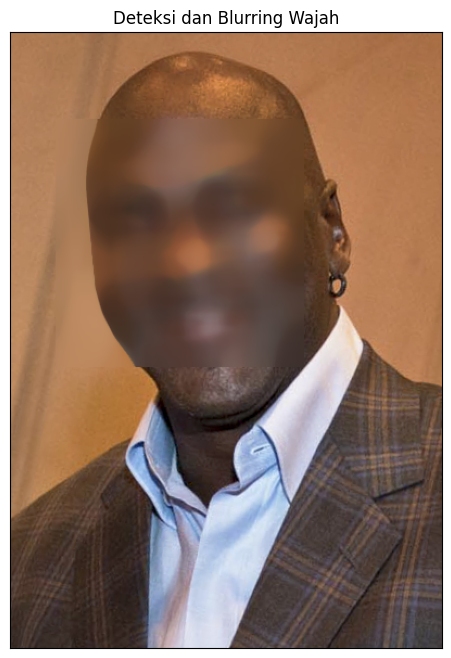

In [54]:
# Muat cascade
face_cascade_path = os.path.join(HAAR_PATH, 'haarcascade_frontalface_alt.xml')
face_cascade = cv.CascadeClassifier(face_cascade_path)

if face_cascade.empty():
    print("Error: Gagal memuat cascade.")
else:
    # Muat gambar (sesuai contoh di modul)
    img_path = os.path.join(BASE_PATH, 'facedet', 'mjordan.jpg')
    img = cv.imread(img_path)
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    # Deteksi wajah
    faces = face_cascade.detectMultiScale(gray, 1.1, 4)

    for (x, y, w, h) in faces:
        # Ambil ROI (Region of Interest) dari wajah
        face_roi = img[y:y+h, x:x+w]

        # Terapkan Median Blur
        blur = cv.medianBlur(face_roi, 35)

        # Kembalikan ROI yang sudah diblur ke gambar asli
        img[y:y+h, x:x+w] = blur

    # Tampilkan hasil
    plt.figure(figsize=(8, 8))
    plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    plt.title('Deteksi dan Blurring Wajah')
    plt.xticks([]), plt.yticks([])
    plt.show()

**KTM**

Wajah terdeteksi dan berhasil di-crop.


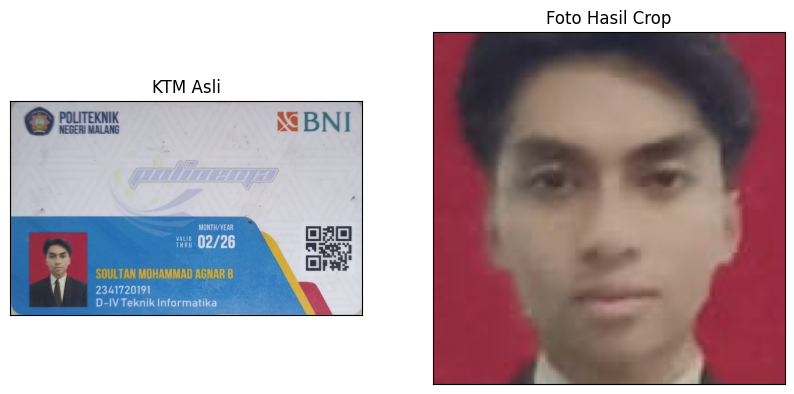

In [9]:
# Muat Haar Cascade classifier untuk wajah
face_cascade_path = os.path.join(HAAR_PATH, 'haarcascade_frontalface_alt.xml')
face_cascade = cv.CascadeClassifier(face_cascade_path)

if face_cascade.empty():
    print(f"Error: Tidak bisa memuat cascade classifier dari {face_cascade_path}")
else:
    # --- GANTI NAMA FILE INI ---
    ktm_path = os.path.join('/content/drive/MyDrive/images/ktm_lama.jpeg')
    ktm_img = cv.imread(ktm_path)

    if ktm_img is None:
        print(f"Error: Gagal memuat {ktm_path}. Pastikan nama file benar.")
    else:
        # Konversi ke grayscale untuk deteksi
        gray = cv.cvtColor(ktm_img, cv.COLOR_BGR2GRAY)

        # Deteksi wajah
        faces = face_cascade.detectMultiScale(gray, 1.1, 5)

        if len(faces) == 0:
            print("Tidak ada wajah yang terdeteksi di KTM.")
            foto_ktm = None # Tandai jika tidak ada wajah
        else:
            # Ambil wajah pertama yang terdeteksi
            (x, y, w, h) = faces[0]

            # Crop gambar asli (berwarna) berdasarkan koordinat wajah
            padding = 10
            y1 = max(0, y - padding)
            y2 = min(ktm_img.shape[0], y + h + padding)
            x1 = max(0, x - padding)
            x2 = min(ktm_img.shape[1], x + w + padding)

            foto_ktm = ktm_img[y1:y2, x1:x2]
            print("Wajah terdeteksi dan berhasil di-crop.")

        # --- Bagian Tampilan (Plotting) ---

        # Buat figure dengan ukuran yang cukup lebar
        plt.figure(figsize=(10, 5))

        # Slot 1: Tampilkan gambar KTM asli
        plt.subplot(1, 2, 1)
        plt.imshow(cv.cvtColor(ktm_img, cv.COLOR_BGR2RGB))
        plt.title('KTM Asli')
        plt.xticks([]), plt.yticks([])

        # Slot 2: Tampilkan foto yang di-crop (jika ada)
        plt.subplot(1, 2, 2)
        if foto_ktm is not None:
            plt.imshow(cv.cvtColor(foto_ktm, cv.COLOR_BGR2RGB))
            plt.title('Foto Hasil Crop')
        else:
            plt.text(0.5, 0.5, 'Wajah Gagal Terdeteksi', horizontalalignment='center')
            plt.title('Foto Hasil Crop')

        plt.xticks([]), plt.yticks([])

        # Tampilkan kedua gambar
        plt.show()

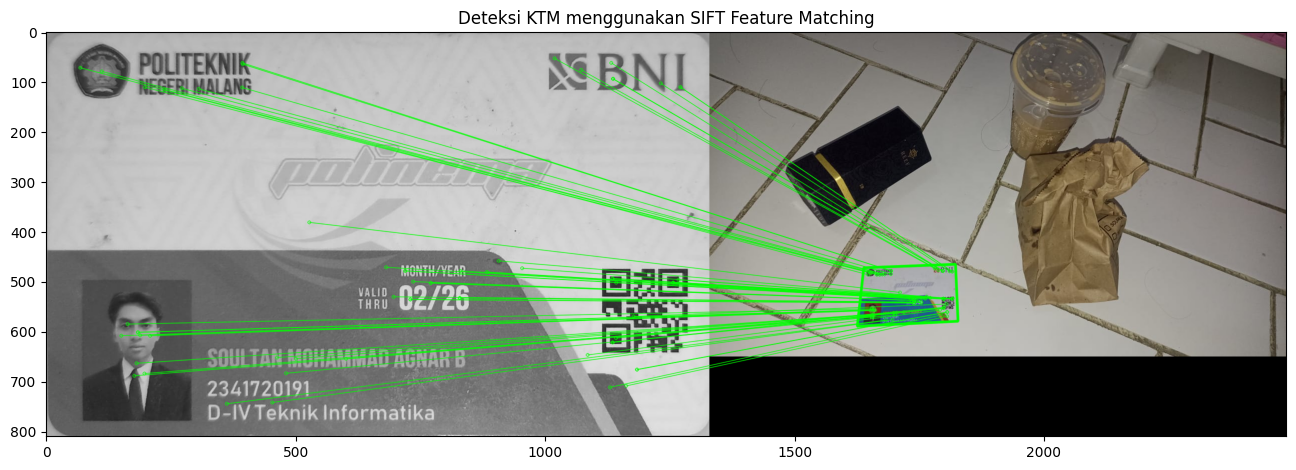

In [10]:
# Muat gambar
try:
    img_template_path = os.path.join('/content/drive/MyDrive/images/ktm_lama.jpeg')
    img_scene_path = os.path.join('/content/drive/MyDrive/images/ktm_scene.jpeg')

    img_template = cv.imread(img_template_path, 0) # Template (grayscale)
    img_scene = cv.imread(img_scene_path)
    img_scene_gray = cv.cvtColor(img_scene, cv.COLOR_BGR2GRAY)

    if img_template is None or img_scene is None:
        raise Exception("Salah satu file gambar tidak ditemukan.")

    # 1. Inisialisasi SIFT detector [cite: 381]
    sift = cv.SIFT_create()

    # 2. Temukan keypoints dan descriptors
    kp1, des1 = sift.detectAndCompute(img_template, None)
    kp2, des2 = sift.detectAndCompute(img_scene_gray, None)

    # 3. Inisialisasi BFMatcher dan k-NN Match
    bf = cv.BFMatcher()
    matches = bf.knnMatch(des1, des2, k=2)

    # 4. Terapkan Ratio Test (Lowe's ratio test) [cite: 388-391]
    good_matches = []
    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            good_matches.append(m)

    # 5. Temukan Homography (jika ada cukup kecocokan)
    MIN_MATCH_COUNT = 10
    if len(good_matches) > MIN_MATCH_COUNT:
        # Ambil koordinat keypoints yang cocok
        src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
        dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

        # Hitung matriks homography
        M, mask = cv.findHomography(src_pts, dst_pts, cv.RANSAC, 5.0)
        matchesMask = mask.ravel().tolist()

        # Dapatkan sudut-sudut dari template
        h, w = img_template.shape
        pts = np.float32([[0, 0], [0, h-1], [w-1, h-1], [w-1, 0]]).reshape(-1, 1, 2)

        # Transformasikan sudut-sudut ke gambar scene
        dst = cv.perspectiveTransform(pts, M)

        # Gambar poligon di sekitar objek yang terdeteksi
        img_scene = cv.polylines(img_scene, [np.int32(dst)], True, (0, 255, 0), 3, cv.LINE_AA)

    else:
        print(f"Tidak cukup kecocokan - hanya {len(good_matches)}/{MIN_MATCH_COUNT}")
        matchesMask = None

    # Gambar hasil kecocokan
    draw_params = dict(matchColor = (0, 255, 0),
                       singlePointColor = None,
                       matchesMask = matchesMask, # Hanya gambar inliers
                       flags = 2)

    img_result = cv.drawMatches(img_template, kp1, img_scene, kp2, good_matches, None, **draw_params)

    # Tampilkan hasil
    plt.figure(figsize=(16, 8))
    plt.imshow(cv.cvtColor(img_result, cv.COLOR_BGR2RGB))
    plt.title('Deteksi KTM menggunakan SIFT Feature Matching')
    plt.show()

except Exception as e:
    print(f"Terjadi error: {e}")
    print("Pastikan Anda memiliki 'ktm_template.jpg' dan 'ktm_scene.jpg' di BASE_PATH.")

# Tambahan Tugas Praktikum: Deep Learning (CNN)

In [11]:
!pip install tqdm

Mempersiapkan folder 0-9...
Folder siap.
Ditemukan 53 potensi angka.
Mulai proses labeling...
Ketik angka (0-9) lalu tekan Enter. Ketik 's' untuk skip gambar.


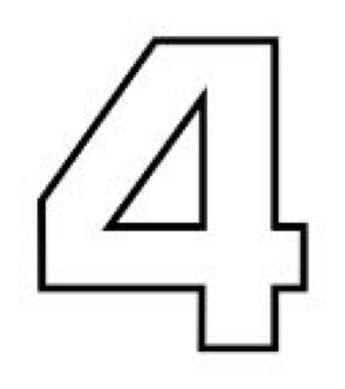

Angka berapakah ini? (0-9, atau 's' untuk skip): 4
Disimpan sebagai /content/drive/MyDrive/images/Object-Detection/dataset/training/4/num_4_1762351300_764.png


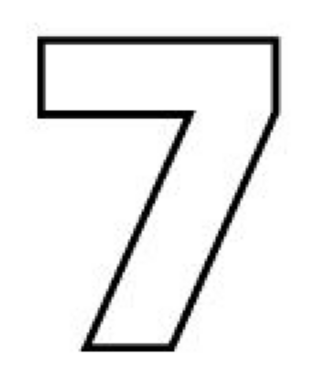

Angka berapakah ini? (0-9, atau 's' untuk skip): 7
Disimpan sebagai /content/drive/MyDrive/images/Object-Detection/dataset/training/7/num_7_1762351303_761.png


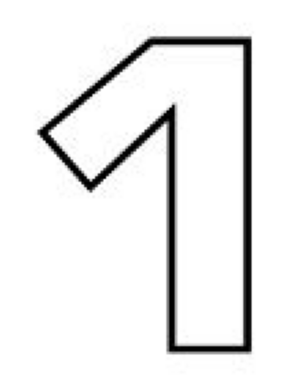

Angka berapakah ini? (0-9, atau 's' untuk skip): 1
Disimpan sebagai /content/drive/MyDrive/images/Object-Detection/dataset/training/1/num_1_1762351306_267.png


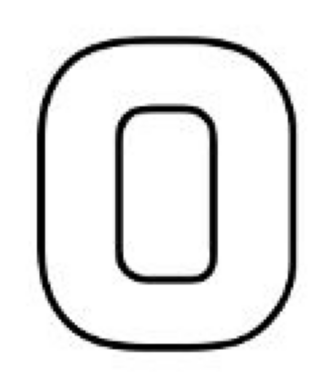

Angka berapakah ini? (0-9, atau 's' untuk skip): 0
Disimpan sebagai /content/drive/MyDrive/images/Object-Detection/dataset/training/0/num_0_1762351309_504.png


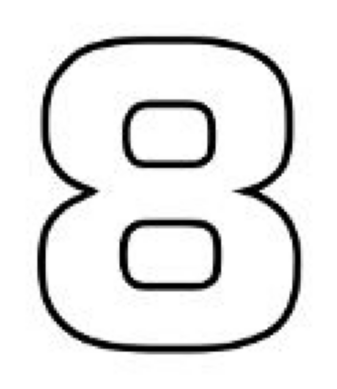

Angka berapakah ini? (0-9, atau 's' untuk skip): 8
Disimpan sebagai /content/drive/MyDrive/images/Object-Detection/dataset/training/8/num_8_1762351313_142.png


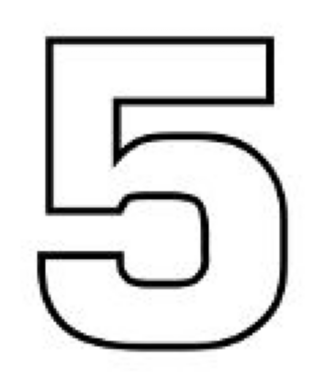

Angka berapakah ini? (0-9, atau 's' untuk skip): 5
Disimpan sebagai /content/drive/MyDrive/images/Object-Detection/dataset/training/5/num_5_1762351315_186.png


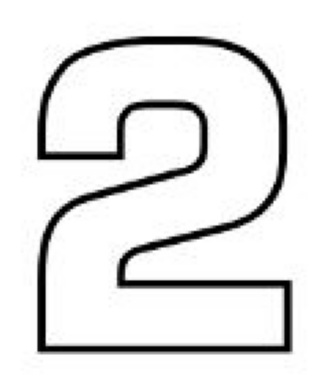

Angka berapakah ini? (0-9, atau 's' untuk skip): 2
Disimpan sebagai /content/drive/MyDrive/images/Object-Detection/dataset/training/2/num_2_1762351320_382.png


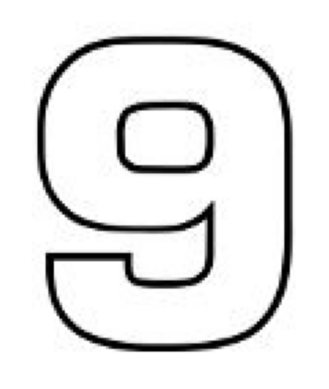

Angka berapakah ini? (0-9, atau 's' untuk skip): 9
Disimpan sebagai /content/drive/MyDrive/images/Object-Detection/dataset/training/9/num_9_1762351323_415.png


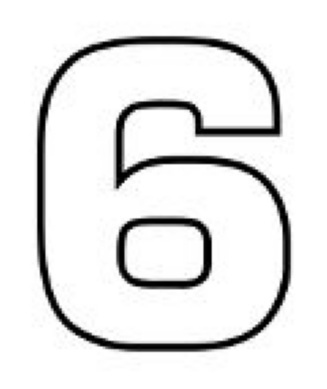

Angka berapakah ini? (0-9, atau 's' untuk skip): 6
Disimpan sebagai /content/drive/MyDrive/images/Object-Detection/dataset/training/6/num_6_1762351332_543.png


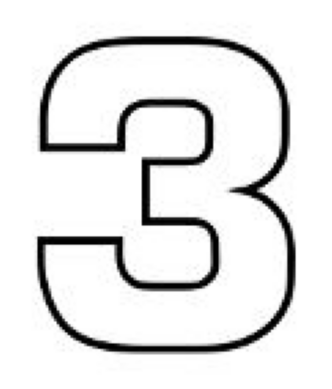

Angka berapakah ini? (0-9, atau 's' untuk skip): 3
Disimpan sebagai /content/drive/MyDrive/images/Object-Detection/dataset/training/3/num_3_1762351336_568.png
Proses labeling selesai!


In [30]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import os
import time
import random

# --- 1. SETUP PATH ---
DATADIR = os.path.join(BASE_PATH, "dataset/training")
NAMA_FILE_GABUNGAN = '/content/drive/MyDrive/images/dataset/training/Printable Number Outlines 0-9 on One Page.jpeg' # Ganti dengan nama file Anda
img_path = os.path.join(BASE_PATH, NAMA_FILE_GABUNGAN)

# --- 2. BUAT FOLDER TUJUAN (0-9) ---
print("Mempersiapkan folder 0-9...")
for i in range(10):
    folder_path = os.path.join(DATADIR, str(i))
    os.makedirs(folder_path, exist_ok=True)
print("Folder siap.")

# --- 3. PROSES GAMBAR GABUNGAN ---
img = cv.imread(img_path)
if img is None:
    print(f"Error: Gagal memuat {img_path}. Pastikan nama file benar.")
else:
    # Konversi ke grayscale
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    _, thresh = cv.threshold(gray, 127, 255, cv.THRESH_BINARY_INV)

    # Temukan kontur (bentuk terluar)
    contours, _ = cv.findContours(thresh, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

    print(f"Ditemukan {len(contours)} potensi angka.")
    print("Mulai proses labeling...")
    print("Ketik angka (0-9) lalu tekan Enter. Ketik 's' untuk skip gambar.")

    # Urutkan kontur dari kiri ke kanan
    contours = sorted(contours, key=lambda c: cv.boundingRect(c)[0])

    # --- 4. LOOPING UNTUK LABELING ---
    for c in contours:
        # Dapatkan kotak pembatas (bounding box)
        (x, y, w, h) = cv.boundingRect(c)

        # Filter kontur yang terlalu kecil (mungkin noise)
        if w < 10 or h < 10:
            continue

        # Crop angka dari gambar grayscale ASLI (bukan threshold)
        # Tambahkan sedikit padding
        padding = 10
        y1 = max(0, y - padding)
        y2 = min(gray.shape[0], y + h + padding)
        x1 = max(0, x - padding)
        x2 = min(gray.shape[1], x + w + padding)

        cropped_num = gray[y1:y2, x1:x2]

        # Tampilkan angka yang di-crop
        plt.imshow(cropped_num, cmap='gray')
        plt.axis('off')
        plt.show()

        # Minta input dari Anda
        try:
            label = input("Angka berapakah ini? (0-9, atau 's' untuk skip): ")
        except EOFError:
            print("Input dibatalkan, menghentikan skrip.")
            break

        # Proses input
        if label.lower() == 's':
            print("Dilewati.")
            continue

        if label.isdigit() and 0 <= int(label) <= 9:
            # Buat nama file unik
            filename = f"num_{label}_{int(time.time())}_{random.randint(100, 999)}.png"
            save_path = os.path.join(DATADIR, label, filename)

            # Simpan gambar yang sudah di-resize (sesuai Sel 16)
            resized_img = cv.resize(cropped_num, (100, 100))
            cv.imwrite(save_path, resized_img)
            print(f"Disimpan sebagai {save_path}")
        else:
            print("Input tidak valid, dilewati.")

    print("Proses labeling selesai!")

In [31]:
import os
import tqdm
import cv2 as cv
import random
import numpy as np
import pickle

# --- SESUAIKAN PATH INI ---
DATADIR = os.path.join("/content/drive/MyDrive/images/Object-Detection/dataset/training")

dirs = []
training_data = []
width, height = 100, 100

if not os.path.exists(DATADIR):
    print(f"Error: Folder {DATADIR} tidak ditemukan.")
    print("Pastikan Anda sudah membuat dataset/training di Google Drive.")
else:
    # Looping direktori data training untuk diambil nama karakternya
    for char_name in sorted(os.listdir(DATADIR)):
        dirs.append(char_name)
    print(f"Karakter ditemukan: {dirs}")

    # Looping semua image data training untuk diubah menjadi array
    for char_name in dirs:
        path = os.path.join(DATADIR, char_name)
        class_number = dirs.index(char_name)

        # Gunakan tqdm untuk progress bar
        for img_name in tqdm.tqdm(os.listdir(path)):
            try:
                # Baca gambar (pastikan path benar)
                img_path = os.path.join(path, img_name)
                img_array = cv.imread(img_path, cv.IMREAD_GRAYSCALE) # Ubah ke grayscale
                if img_array is None:
                    continue

                new_array = cv.resize(img_array, (width, height))
                training_data.append([new_array, class_number])
            except Exception as e:
                print(f"Error membaca {img_path}: {e}")
                pass

    random.shuffle(training_data)

    X = []
    y = []

    for feature, label in training_data:
        X.append(feature)
        y.append(label)

    X = np.array(X).reshape(-1, width, height, 1)

    # Tulis ke file pickle [cite: 823-828]
    pickle_out = open("X.pickle", "wb")
    pickle.dump(X, pickle_out)
    pickle_out.close()

    pickle_out = open("y.pickle", "wb")
    pickle.dump(y, pickle_out)
    pickle_out.close()

    print("File X.pickle dan y.pickle berhasil dibuat.")

Karakter ditemukan: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


100%|██████████| 2/2 [00:00<00:00, 171.74it/s]

File X.pickle dan y.pickle berhasil dibuat.


In [32]:
# Sel 17: Training Data (Model CNN) - PERBAIKAN

import pickle
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, ZeroPadding2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
import numpy as np

# Load file pickle
try:
    pickle_in = open("X.pickle", "rb")
    X = pickle.load(pickle_in)
    pickle_in.close()

    pickle_in = open("y.pickle", "rb")
    y = pickle.load(pickle_in)
    pickle_in.close()

    # Normalisasi data
    X = X / 255.0

    # Ubah label ke one-hot encoding
    y = to_categorical(y)

    num_classes = y.shape[1]
    print(f"Data di-load. Jumlah kelas: {num_classes}")

    width, height = 100, 100

    # Input layer
    inputs = Input(shape=(width, height, 1))

    # Arsitektur CNN [cite: 858-869]
    conv_layer = ZeroPadding2D(padding=(2, 2))(inputs)
    conv_layer = Conv2D(16, (5, 5), strides=(1, 1), activation='relu')(conv_layer)
    conv_layer = MaxPooling2D((2, 2))(conv_layer)

    conv_layer = Conv2D(32, (3, 3), strides=(1, 1), activation='relu')(conv_layer)
    conv_layer = Conv2D(32, (3, 3), strides=(1, 1), activation='relu')(conv_layer)
    conv_layer = MaxPooling2D((2, 2))(conv_layer)

    conv_layer = Conv2D(64, (3, 3), strides=(1, 1), activation='relu')(conv_layer)

    flaten = Flatten()(conv_layer)

    fc_layer = Dense(256, activation='relu')(flaten)
    fc_layer = Dense(64, activation='relu')(flaten)

    # Output layer
    outputs = Dense(num_classes, activation='softmax')(fc_layer)

    # Buat model
    model = Model(inputs=inputs, outputs=outputs)

    adam = Adam(learning_rate=0.0001)

    model.compile(optimizer=adam, loss='categorical_crossentropy', metrics=['accuracy'])

    model.summary()

    # Training model
    model.fit(X, y, epochs=20, verbose=1, validation_split=0.1)

    # --- PERBAIKAN DI SINI ---
    # Gunakan ekstensi .keras atau .h5
    model.save('anpr.keras')
    print("Model berhasil disimpan sebagai 'anpr.keras'")
    # --- AKHIR PERBAIKAN ---

except FileNotFoundError:
    print("Error: File X.pickle atau y.pickle tidak ditemukan.")
    print("Pastikan Anda sudah menjalankan sel 'Persiapan Data Training' sebelumnya.")

Data di-load. Jumlah kelas: 10


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 100, 100, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ zero_padding2d_2                │ (None, 104, 104, 1)    │             0 │
│ (ZeroPadding2D)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 100, 100, 16)   │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 50, 50, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 48, 48, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 46, 46, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 28224)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │     1,806,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,839,850 (7.02 MB)

 Trainable params: 1,839,850 (7.02 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.1111 - loss: 2.3056 - val_accuracy: 0.0000e+00 - val_loss: 2.4279
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - accuracy: 0.1667 - loss: 2.2820 - val_accuracy: 0.0000e+00 - val_loss: 2.5175
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.1111 - loss: 2.2662 - val_accuracy: 0.0000e+00 - val_loss: 2.5990
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - accuracy: 0.2778 - loss: 2.2502 - val_accuracy: 0.0000e+00 - val_loss: 2.6719
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step - accuracy: 0.1667 - loss: 2.2358 - val_accuracy: 0.0000e+00 - val_loss: 2.7427
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - accuracy: 0.1667 - loss: 2.2197 - val_accuracy: 0.0000e+00 - val_loss: 2.8088
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.1667 - loss: 2.2038 - val_accuracy: 0.0000e+00 - val_loss: 2.8779
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - accuracy: 0.1667 - loss: 2.1855 - val_acc

In [39]:
# Sel 18: Testing Data - PERBAIKAN

import os
import cv2 as cv
import tensorflow as tf
import numpy as np

DATA_DIR_TRAINING = os.path.join('/content/drive/MyDrive/images/Object-Detection/dataset/training')
DATA_DIR_TESTING = os.path.join('/content/drive/MyDrive/images/Object-Detection/dataset/training')

if not os.path.exists(DATA_DIR_TESTING) or not os.path.exists(DATA_DIR_TRAINING):
    print("Error: Folder dataset training atau testing tidak ditemukan.")
else:
    dirs = []
    width, height = 100, 100

    # Muat model
    try:
        # --- PERBAIKAN DI SINI ---
        model = tf.keras.models.load_model("anpr.keras")
        # --- AKHIR PERBAIKAN ---

        # Muat label karakter dari folder training
        for char_name in sorted(os.listdir(DATA_DIR_TRAINING)):
            if os.path.isdir(os.path.join(DATA_DIR_TRAINING, char_name)):
                dirs.append(char_name)
        print(f"Label model: {dirs}")

        # Looping folder testing
        for car_folder in sorted(os.listdir(DATA_DIR_TESTING)):
            temp_result = ""
            folder_path = os.path.join(DATA_DIR_TESTING, car_folder)

            if not os.path.isdir(folder_path):
                continue

            # Looping file gambar karakter di dalam folder
            for char_img_name in sorted(os.listdir(folder_path)):
                try:
                    img_path = os.path.join(folder_path, char_img_name)
                    img_array = cv.imread(img_path, cv.IMREAD_GRAYSCALE)

                    if img_array is None:
                        continue

                    # Preprocessing gambar
                    new_array = cv.resize(img_array, (width, height))
                    new_array = np.array(new_array).reshape(-1, width, height, 1)
                    new_array = new_array / 255.0

                    # Prediksi
                    prediction = model.predict(new_array)

                    # Dapatkan karakter dengan probabilitas tertinggi
                    predicted_char = dirs[np.argmax(prediction[0])]
                    temp_result += predicted_char

                except Exception as e:
                    print(f"Error memproses {char_img_name}: {e}")

            print("-----------------------------------------")
            print(f"Folder: {car_folder} | Hasil Prediksi: {temp_result}")
            print("-----------------------------------------")

    except Exception as e:
        print(f"Error saat testing: {e}")
        print("Pastikan model 'anpr.keras' sudah ada dari sel training.")

Label model: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
-----------------------------------------
Folder: 0 | Hasil Prediksi: 80
-----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
-----------------------------------------
Folder: 1 | Hasil Prediksi: 11
-----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
-----------------------------------------
Folder: 2 | Hasil Prediksi: 22
-----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
-----------------------------------------
Folder: 3 | Hasil Prediksi: 89
-----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
-----------------------------------------
Folder: 4 | Hasil Prediksi: 44
----------------------

Model dan label berhasil dimuat. Label: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Ditemukan 11 kontur angka (setelah closing).
      HASIL PREDIKSI: 4710892969      


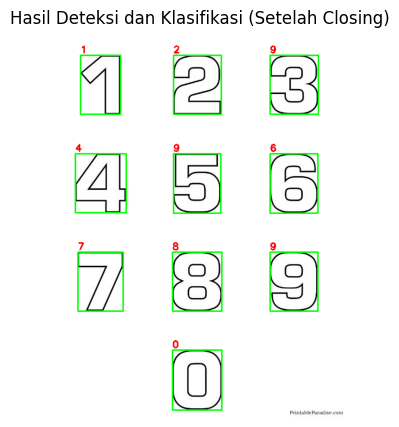

In [42]:
# Sel 19: Deteksi + Klasifikasi pada 1 Gambar (Perbaikan)

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import os
import tensorflow as tf

# --- 1. MUAT MODEL DAN LABEL ---
try:
    model = tf.keras.models.load_model("anpr.keras")

    DATA_DIR_TRAINING = os.path.join("/content/drive/MyDrive/images/Object-Detection/dataset/training")
    dirs = []
    for char_name in sorted(os.listdir(DATA_DIR_TRAINING)):
        if os.path.isdir(os.path.join(DATA_DIR_TRAINING, char_name)):
            dirs.append(char_name)
    print(f"Model dan label berhasil dimuat. Label: {dirs}")

except Exception as e:
    print(f"Error memuat model atau label: {e}")

# --- 2. MUAT GAMBAR UJI ---
NAMA_FILE_UJI = '/content/drive/MyDrive/images/dataset/training/angka.jpeg'
img_path = os.path.join(NAMA_FILE_UJI)

img = cv.imread(img_path)
if img is None:
    print(f"Error: Gagal memuat {img_path}")
else:
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    img_ori = img.copy()

    # --- 3. PROSES 1: DETEKSI ---

    # (cv.THRESH_BINARY_INV) = Angka gelap, background terang
    _, thresh = cv.threshold(gray, 127, 255, cv.THRESH_BINARY_INV)

    # --- LANGKAH TAMBAHAN: MORPHOLOGICAL CLOSING ---

    kernel = np.ones((5,5), np.uint8)
    closing = cv.morphologyEx(thresh, cv.MORPH_CLOSE, kernel)
    # --- AKHIR LANGKAH TAMBAHAN ---

    # Gunakan 'closing' (gambar yang sudah diperbaiki) untuk findContours
    contours, _ = cv.findContours(closing, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

    print(f"Ditemukan {len(contours)} kontur angka (setelah closing).")

    contours = sorted(contours, key=lambda c: cv.boundingRect(c)[0])

    hasil_prediksi = ""

    # --- 4. PROSES 2: KLASIFIKASI ---

    for c in contours:
        (x, y, w, h) = cv.boundingRect(c)

        if w < 5 or h < 10:
            continue

        cv.rectangle(img_ori, (x, y), (x + w, y + h), (0, 255, 0), 2)

        # Crop angka dari gambar grayscale ASLI (bukan 'closing')
        padding = 10
        y1 = max(0, y - padding)
        y2 = min(gray.shape[0], y + h + padding)
        x1 = max(0, x - padding)
        x2 = min(gray.shape[1], x + w + padding)

        cropped_num = gray[y1:y2, x1:x2]

        # --- Preprocessing untuk Model ---
        resized_num = cv.resize(cropped_num, (100, 100))
        processed_num = np.array(resized_num).reshape(-1, 100, 100, 1)
        processed_num = processed_num / 255.0

        # --- Prediksi ---
        prediction = model.predict(processed_num, verbose=0) # Set verbose=0 agar tidak 'spam'
        predicted_char = dirs[np.argmax(prediction[0])]

        hasil_prediksi += predicted_char
        cv.putText(img_ori, predicted_char, (x, y - 5), cv.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

    # --- 5. TAMPILKAN HASIL ---
    print("====================================")
    print(f"      HASIL PREDIKSI: {hasil_prediksi}      ")
    print("====================================")

    plt.figure(figsize=(10, 5))
    plt.imshow(cv.cvtColor(img_ori, cv.COLOR_BGR2RGB))
    plt.title("Hasil Deteksi dan Klasifikasi (Setelah Closing)")
    plt.axis('off')
    plt.show()